# 1. Notebook Contract

This notebook is part of the **Home Credit Default Risk** machine learning project. In the previous notebook, multiple related datasets were integrated into one applicant-level dataset. Now, before moving into preprocessing, feature engineering, or modeling, we need to understand the data carefully.

The purpose of this notebook is not to rush into building a model. The purpose is to collect clear, structured, and reusable information about the dataset so that later decisions are based on evidence, not assumptions.

This EDA will be divided into two major parts:

**First, Univariate Analysis.**
In this part, we will study each feature individually. We will look at feature identity, data type, missing values, numerical behavior, categorical behavior, distribution shape, outliers, cardinality, and possible preprocessing hints such as imputation, scaling, encoding, and transformation needs.

**Second, Thinking Analysis.**
In this part, we will move beyond simple statistics. We will think about the target variable, feature groups, credit-risk logic, feature usefulness, train-test stability, feature extraction ideas, and feature selection evidence.

This notebook will not permanently transform the dataset. We will not perform final imputation, final scaling, final encoding, final feature dropping, oversampling, or model training here. Those steps will be handled in later notebooks after this EDA gives us enough information.

The working style of this notebook will be:

**Question → Evidence → Observation → Decision Hint**

Every section should answer a clear question. If a table gives the information clearly, we will use a table. Plots will be used only when they help us understand a pattern better.

By the end of this notebook, we should have a clean understanding of the dataset, reusable feature-level evidence, preprocessing hints, feature extraction ideas, and feature selection guidance for the next stages of the machine learning pipeline.


## 1.1 Purpose of This Notebook

The purpose of this notebook is to understand the integrated Home Credit dataset before making any preprocessing, feature engineering, or modeling decisions.

At this stage, the goal is not to modify the data permanently. The goal is to collect clear evidence about the dataset so that the next steps can be planned with proper reasoning.

### Main Objectives

| Objective                       | What We Want to Understand                                                                            |
| ------------------------------- | ----------------------------------------------------------------------------------------------------- |
| Understand dataset readiness    | Whether the integrated train and test datasets are structurally safe for EDA                          |
| Understand feature behavior     | How individual features behave in terms of missing values, distribution, outliers, and cardinality    |
| Understand preprocessing needs  | Which features may later need imputation, scaling, encoding, clipping, or transformation              |
| Understand target behavior      | How the default-risk target is distributed and how imbalanced the problem is                          |
| Understand feature usefulness   | Which features or feature groups may carry useful information for default-risk prediction             |
| Understand feature risks        | Which features may be noisy, unstable, highly missing, redundant, or potentially misleading           |
| Prepare next notebook decisions | Create evidence that will support preprocessing, feature engineering, feature selection, and modeling |

### How This Notebook Will Help Later

| EDA Information         | Later Decision It Supports                                              |
| ----------------------- | ----------------------------------------------------------------------- |
| Missing value patterns  | Imputation strategy and missing-flag creation                           |
| Numerical distributions | Scaling, clipping, log transformation, or binning decisions             |
| Outlier behavior        | Whether extreme values should be reviewed, capped, transformed, or kept |
| Categorical cardinality | Encoding strategy such as one-hot, frequency, or rare-category grouping |
| Target distribution     | Validation strategy and model evaluation metric selection               |
| Feature-group behavior  | Which data sources may be more useful for prediction                    |
| Train-test stability    | Whether a feature is safe and stable for modeling                       |
| Feature-target evidence | Feature selection and feature extraction planning                       |

### Core Idea

This notebook is designed as an evidence-generation notebook.
Every analysis should help us answer one question:

**What do we need to know before transforming features and building models?**


## 1.2 Non-goals

This notebook is focused on understanding the data, not permanently changing it.  
We may identify problems, risks, and possible treatment ideas here, but final implementation will be handled in later notebooks.

| Non-goal | Why It Does Not Belong Here | Later Stage |
|---|---|---|
| Permanent feature dropping | EDA should collect evidence first; final dropping should be supported by data quality, business logic, and validation results | Feature Selection |
| Final imputation | Imputation changes feature values and should be fitted carefully in a preprocessing pipeline | Preprocessing |
| Final scaling | Scaling depends on the model type and should be handled inside a model-specific pipeline | Preprocessing / Modeling |
| Final encoding | Encoding decisions depend on feature type, cardinality, model choice, and leakage-safe design | Preprocessing / Feature Engineering |
| Outlier capping or clipping | Outliers should be understood first before deciding whether they are errors, rare values, or useful risk signals | Feature Transformation |
| Log transformation or binning | These are actual feature transformations, so they should not be applied permanently during EDA | Feature Transformation |
| Oversampling or class balancing | Class balancing is part of model training strategy, not data understanding | Modeling |
| Target encoding | Target encoding is leakage-sensitive and must be applied carefully inside validation folds | Feature Engineering / Modeling |
| Final model training | This notebook is for data understanding, not model fitting | Modeling |
| Hyperparameter tuning | Tuning requires validated model experiments, which belong to the modeling stage | Modeling |
| Final prediction or submission | Final prediction should happen only after preprocessing, feature engineering, feature selection, and model validation | Final Modeling |

### Default Rule

If an action permanently changes feature values, removes features, fits transformers, balances classes, selects final features, or trains a model, it does not belong in this EDA notebook.

## 1.3 Required Inputs

Before starting the EDA, we need to clearly define the inputs used in this notebook.  
This helps keep the workflow reproducible and prevents confusion between training data, test data, identifiers, target labels, and optional metadata.

### Required Inputs

| Input | Description | Why It Is Needed |
|---|---|---|
| Integrated train dataset | Applicant-level training dataset created from the data integration stage | Used for feature profiling, target analysis, and feature-target relationship analysis |
| Integrated test dataset | Applicant-level test dataset created from the data integration stage | Used for structure alignment and train-test stability checks |
| `SK_ID_CURR` | Unique applicant identifier | Used to check duplicate applicants and track applicant-level records |
| `TARGET` | Default-risk label available only in the train dataset | Used for target distribution and feature-target analysis |
| Feature columns | All usable columns except identifier, target, and accidental index columns | Used for univariate analysis and feature intelligence |

### Optional Inputs

| Optional Input | Description | How It Helps |
|---|---|---|
| Data dictionary | Description of original Home Credit variables | Helps understand business meaning of features |
| Feature-source map | Mapping of each feature to its original data source | Helps group features by application, bureau, previous application, installments, credit card, POS cash, etc. |
| Feature-family map | Mapping of features into families such as amount, ratio, count, flag, categorical, or aggregation | Helps plan imputation, scaling, encoding, and transformation strategies |
| Save paths | Folder paths for saving EDA reports and summary tables | Helps reuse EDA outputs in later notebooks |
| Configuration values | Target name, key column, source prefixes, and reporting thresholds | Keeps the notebook clean, reusable, and easier to update |

### Input Assumption

The train and test datasets are expected to come from the same integration pipeline.  
The train dataset should contain the `TARGET` column, while the test dataset should not contain `TARGET`.

If optional metadata is not available, this notebook will still run, but some business interpretation and feature-group analysis may be less detailed.

## 1.4 Expected Notebook Outputs

This notebook should produce compact and reusable evidence, not scattered observations.  
All important outputs should be visible inside the notebook as summary tables. Saving reports is optional and only for reuse in later notebooks.

| Expected Output | Why It Matters |
|---|---|
| Dataset health summary | Confirms whether the integrated train and test datasets are structurally ready for EDA |
| Feature inventory | Helps understand feature role, source group, data type, and feature family |
| Missing value summary | Supports later imputation strategy and missing-flag decisions |
| Numerical feature profile | Supports later decisions about scaling, clipping, log transformation, and outlier review |
| Categorical feature profile | Supports later decisions about encoding, rare-category grouping, and missing-category handling |
| Target summary | Helps understand class imbalance, validation strategy, and evaluation metrics |
| Feature-group summary | Helps identify which data sources may contain stronger risk information |
| Train-test stability summary | Helps detect unstable features before modeling |
| Feature extraction idea list | Provides structured ideas for the feature engineering notebook |
| Feature selection evidence summary | Helps decide which features should be kept, reviewed, or tested later |

The final output of this notebook should be a clear evidence base for the next stages: preprocessing, feature engineering, feature selection, and modeling.

---

## 1.5 Default Rule

The default rule of this notebook is simple:

**Understand first, transform later.**

In this notebook, we can inspect, compare, summarize, and mark possible issues.  
However, any action that permanently changes the dataset should be handled in a later notebook.

| Allowed in This Notebook | Not Allowed as Final Action Here |
|---|---|
| Identify missing values | Final imputation |
| Detect outliers | Final clipping or capping |
| Study skewness | Final log transformation |
| Check categorical cardinality | Final encoding |
| Mark weak or risky features | Final feature dropping |
| Study target imbalance | Oversampling or class balancing |
| Compare train and test distributions | Final feature removal based only on EDA |
| Collect feature ideas | Final feature engineering implementation |
| Collect feature selection evidence | Final model-based feature selection |
| Understand model needs | Final model training |

If an action changes feature values, removes features, fits transformers, balances classes, selects final features, or trains a model, it does not belong in this EDA notebook.

## 1.6 Load Dataset

In this step, we only load the integrated train and test datasets.

No data checking will be performed here. Dataset shape, duplicate keys, missing values, column alignment, accidental index columns, and other health checks will be handled later in the Univariate Analysis section.

This keeps the notebook flow clean:

**Load first → Understand later → Decide after evidence**

In [1]:
# Import required libraries
import pandas as pd
from pathlib import Path

# Define dataset folder from the Notebook directory
DATA_DIR = Path("..") / "Data" / "Processed"

# Define dataset paths
TRAIN_PATH = DATA_DIR / "home_credit_train_integrated.parquet"
TEST_PATH = DATA_DIR / "home_credit_test_integrated.parquet"

# Define key and target columns
KEY_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"

# Load integrated datasets
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

# 2. Univariate Analysis 🔍

In this section, we study each feature individually to understand its basic behavior, quality, and preprocessing needs.

The main goal is not to change the data here.  
The goal is to collect clean feature-level evidence that will help us make better decisions later.

### 🎯 Main Target

For every feature, we want to understand:

| Question | Why It Matters |
|---|---|
| What is this feature? | To understand its role, source, and meaning |
| How clean is it? | To detect missing values, constants, duplicates, and unusual patterns |
| How does it behave? | To understand distribution, skewness, zero values, and outliers |
| What type of feature is it? | To plan numeric, categorical, binary, or flag-based handling |
| What information should we keep? | To build a reusable feature evidence table for later analysis |

### 🧠 Working Principle

**Collect information first. Decide later.**

This section will create evidence tables for all features, but it will not perform final imputation, scaling, encoding, feature dropping, or model training.

### 📌 Expected Outputs

By the end of this section, we should have:

- dataset health evidence  
- feature inventory  
- missingness profile  
- numeric feature profile  
- categorical feature profile  
- distribution and outlier evidence  
- one master univariate feature evidence file  

These outputs will support the next stages: preprocessing, feature engineering, feature selection, and modeling.

## Manual Feature Grouping Setup

Before starting the main univariate analysis, we prepared a manual feature grouping map from the sample integrated dataset.

The purpose of this step is not to make final preprocessing decisions.  
The purpose is to create a clean routing map so that each feature can be analyzed in the correct EDA section.

### What Was Grouped

Each column was reviewed and assigned basic metadata:

| Metadata Field | Meaning |
|---|---|
| `role` | Whether the column is an ID, target, model feature, or accidental index artifact |
| `source_group` | The original data source or feature block, such as application, bureau, installments, credit card, POS cash, previous application, or history flag |
| `dtype_semantic` | Human-understood data type such as numeric, categorical, binary, or duration-like |
| `feature_family` | Business/statistical family such as amount, ratio, count, flag, score, aggregation, or duration |
| `profile_route` | Which univariate profile section should analyze the feature later |

### Current Grouping Summary

| Item | Count |
|---|---:|
| Total columns | 2,569 |
| Index artifact | 1 |
| ID column | 1 |
| Target column | 1 |
| Model candidate features | 2,566 |
| Numeric features | 2,259 |
| Binary / flag features | 152 |
| Duration-like features | 143 |
| Categorical features | 12 |

### Source Group Summary

| Source Group | Feature Count |
|---|---:|
| Credit card | 1,046 |
| Installments | 500 |
| POS cash | 325 |
| Previous application | 226 |
| Bureau | 223 |
| Bureau balance | 120 |
| Application | 120 |
| History flag | 6 |
| Special columns | 3 |

### Important Note

This feature grouping is only an initial EDA support layer.  
It does not decide which features should be kept, dropped, imputed, scaled, encoded, or transformed.

Final decisions will be made later after reviewing the full univariate evidence, business meaning, train-test stability, and modeling results.

In short:

**Feature grouping = routing and understanding**  
**Feature decision = later analysis**

## 2.1 Dataset Health Check

Before studying individual features, we first take a quick look at the structural health of the integrated train and test datasets.

This step is intentionally simple.  
We are not fixing anything here, and we are not making feature-level decisions.

The goal is only to answer:

**Are the train and test datasets structurally ready for univariate analysis?**

We will check:

- dataset size  
- target and key column presence  
- duplicate applicant keys  
- train-test feature alignment  
- accidental index columns  
- all-null and constant column counts  

Any issue found here will be marked for later review, not fixed immediately.

In [2]:
# Basic dataset size and column presence

dataset_health = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [train_df.shape[0], test_df.shape[0]],
    "columns": [train_df.shape[1], test_df.shape[1]],
    "target_present": [TARGET_COL in train_df.columns, TARGET_COL in test_df.columns],
    "key_present": [KEY_COL in train_df.columns, KEY_COL in test_df.columns]
})

dataset_health

,dataset,rows,columns,target_present,key_present
0,train,307511,2568,True,True
1,test,48744,2567,False,True


In [3]:
# Duplicate applicant keys

duplicate_key_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "duplicate_key_rows": [
        train_df.duplicated(subset=[KEY_COL]).sum() if KEY_COL in train_df.columns else None,
        test_df.duplicated(subset=[KEY_COL]).sum() if KEY_COL in test_df.columns else None
    ],
    "unique_key_count": [
        train_df[KEY_COL].nunique() if KEY_COL in train_df.columns else None,
        test_df[KEY_COL].nunique() if KEY_COL in test_df.columns else None
    ]
})

duplicate_key_summary

,dataset,duplicate_key_rows,unique_key_count
0,train,0,307511
1,test,0,48744


In [4]:
# Train-test column alignment information

train_features = set(train_df.columns) - {TARGET_COL}
test_features = set(test_df.columns)

column_alignment = pd.DataFrame({
    "metric": [
        "train_features_excluding_target",
        "test_features",
        "common_features",
        "train_only_features",
        "test_only_features"
    ],
    "value": [
        len(train_features),
        len(test_features),
        len(train_features & test_features),
        len(train_features - test_features),
        len(test_features - train_features)
    ]
})

column_alignment

,metric,value
0,train_features_excluding_target,2567
1,test_features,2567
2,common_features,2567
3,train_only_features,0
4,test_only_features,0


In [5]:
# Accidental index-like columns

index_like_columns = {
    "train": [
        col for col in train_df.columns
        if col.lower().startswith("unnamed") or col.lower() in ["index", "level_0"]
    ],
    "test": [
        col for col in test_df.columns
        if col.lower().startswith("unnamed") or col.lower() in ["index", "level_0"]
    ]
}

index_like_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "index_like_column_count": [
        len(index_like_columns["train"]),
        len(index_like_columns["test"])
    ],
    "index_like_columns": [
        index_like_columns["train"],
        index_like_columns["test"]
    ]
})

index_like_summary

,dataset,index_like_column_count,index_like_columns
0,train,0,[]
1,test,0,[]


In [6]:
# All-null and constant column counts

basic_column_quality = pd.DataFrame({
    "dataset": ["train", "test"],
    "all_null_columns": [
        train_df.isna().all().sum(),
        test_df.isna().all().sum()
    ],
    "constant_columns": [
        sum(train_df[col].nunique(dropna=False) == 1 for col in train_df.columns),
        sum(test_df[col].nunique(dropna=False) == 1 for col in test_df.columns)
    ]
})

basic_column_quality

,dataset,all_null_columns,constant_columns
0,train,0,0
1,test,0,11


### 2.1 Manual Observation

From the tables above, we will manually check:

- whether train and test are loaded properly  
- whether `TARGET` exists only in train  
- whether `SK_ID_CURR` is available  
- whether duplicate applicant keys exist  
- whether train and test feature counts are aligned  
- whether any accidental index-like column exists  
- whether all-null or constant columns need later review  

No action is taken in this section.  
Any issue found here will be carried forward into the feature-level EDA and later preprocessing decisions.

## 2.2 Feature Grouping / Feature Inventory

In this section, we load the manual feature inventory created before starting the main EDA.

This inventory is not a final decision table.  
It is only a routing map that helps us understand each feature by role, source group, semantic type, feature family, and profile route.

We will use this table as a reference for the next univariate sections.

In [18]:
# Load manual feature inventory and feature lists

import pandas as pd
from pathlib import Path
import eda_feature_lists as feature_lists

FEATURE_INVENTORY_PATH = Path("manual_feature_inventory_from_sample.csv")

feature_inventory = pd.read_csv(FEATURE_INVENTORY_PATH)

feature_inventory_shape = pd.DataFrame({
    "item": ["rows", "columns"],
    "value": [feature_inventory.shape[0], feature_inventory.shape[1]]
})

feature_inventory_preview = feature_inventory.head()

inventory_columns = pd.DataFrame({
    "column_name": feature_inventory.columns.tolist()
})

In [19]:
# Create compact grouping summaries

role_summary = feature_inventory["role"].value_counts(dropna=False).reset_index()
role_summary.columns = ["role", "feature_count"]

source_group_summary = feature_inventory["source_group"].value_counts(dropna=False).reset_index()
source_group_summary.columns = ["source_group", "feature_count"]

semantic_type_summary = feature_inventory["dtype_semantic"].value_counts(dropna=False).reset_index()
semantic_type_summary.columns = ["dtype_semantic", "feature_count"]

feature_family_summary = feature_inventory["feature_family"].value_counts(dropna=False).reset_index()
feature_family_summary.columns = ["feature_family", "feature_count"]

profile_route_summary = feature_inventory["profile_route"].value_counts(dropna=False).reset_index()
profile_route_summary.columns = ["profile_route", "feature_count"]

feature_list_summary = pd.DataFrame([
    {"list_name": name, "feature_count": len(value)}
    for name, value in vars(feature_lists).items()
    if isinstance(value, list)
]).sort_values("feature_count", ascending=False)

In [20]:
# Display feature inventory summaries

display(feature_inventory_shape)
display(feature_inventory_preview)
display(role_summary)
display(source_group_summary)
display(semantic_type_summary)
display(feature_family_summary)
display(profile_route_summary)
display(feature_list_summary)

,item,value
0,rows,2569
1,columns,9


,feature,role,source_group,dtype_raw,dtype_semantic,feature_family,profile_route,is_model_candidate,manual_note
0,Unnamed: 0,index_artifact,special,int64,index_artifact,index_artifact,index_artifact,False,Saved index column from CSV export; exclude fr...
1,SK_ID_CURR,id,special,int64,id,id,id,False,"Applicant key; useful for checks, not as model..."
2,TARGET,target,special,int64,target,target,target,False,Target label; used only in target/thinking ana...
3,NAME_CONTRACT_TYPE,model_feature,application,object,categorical,category,categorical_profile,True,Text/category feature; profile cardinality and...
4,CODE_GENDER,model_feature,application,object,binary,flag,binary_profile,True,Binary/flag feature; profile missingness and v...


,role,feature_count
0,model_feature,2566
1,index_artifact,1
2,id,1
3,target,1


,source_group,feature_count
0,credit_card,1046
1,installments,500
2,pos_cash,325
3,previous_application,226
4,bureau,223
5,bureau_balance,120
6,application,120
7,history_flag,6
8,special,3


,dtype_semantic,feature_count
0,numeric,2259
1,binary,152
2,duration_like,143
3,categorical,12
4,target,1
5,index_artifact,1
6,id,1


,feature_family,feature_count
0,ratio,820
1,count,654
2,amount,525
3,flag,152
4,days_duration,141
5,risk_behavior,125
6,property_measure,43
7,mean_agg,23
8,max_agg,22
9,sum_agg,22


,profile_route,feature_count
0,numeric_profile,2259
1,binary_profile,152
2,duration_profile,143
3,categorical_profile,12
4,target,1
5,index_artifact,1
6,id,1


,list_name,feature_count
0,ALL_FEATURES,2569
4,MODEL_FEATURES,2566
5,NUMERIC_FEATURES,2259
25,AGGREGATED_FEATURES,2062
15,CREDIT_CARD_FEATURES,1046
18,RATIO_FEATURES,820
19,COUNT_FEATURES,654
27,MAX_AGG_FEATURES,606
26,MEAN_AGG_FEATURES,605
17,AMOUNT_FEATURES,525


In [21]:
# Save all feature grouping summaries into one sectioned CSV file

OUTPUT_PATH = Path("feature_grouping_summary_report.csv")

summary_tables = {
    "feature_inventory_shape": feature_inventory_shape,
    "inventory_columns": inventory_columns,
    "role_summary": role_summary,
    "source_group_summary": source_group_summary,
    "semantic_type_summary": semantic_type_summary,
    "feature_family_summary": feature_family_summary,
    "profile_route_summary": profile_route_summary,
    "feature_list_summary": feature_list_summary
}

with open(OUTPUT_PATH, "w", encoding="utf-8") as file:
    for table_name, table in summary_tables.items():
        file.write(table_name + "\n")
        table.to_csv(file, index=False)
        file.write("\n\n")

OUTPUT_PATH

WindowsPath('feature_grouping_summary_report.csv')

### 2.2 Manual Observation

The manual feature grouping report shows that the integrated dataset is heavily numeric.

Most of the model candidate features are numerical, aggregated, ratio-based, count-based, amount-based, or duration-like features. Categorical features are very limited compared to the total feature space.

From the feature grouping summary:

| Area | Manual Interpretation |
|---|---|
| Numeric-heavy feature space | Most features are numerical, so numeric profiling will be the most important part of univariate analysis |
| Ratio and count features | Many features already represent financial burden, behaviour frequency, or aggregated history |
| Large aggregated feature blocks | Credit card, installments, POS cash, previous application, and bureau groups contribute many derived features |
| Small categorical block | Categorical encoding will be needed, but it is not the main complexity of this dataset |
| Duration-like features | `DAYS_` and time-related features need careful interpretation because negative values may be valid |

### Early Modeling Direction

Based only on the feature grouping structure, this dataset looks more suitable for numerical tree-boosting models such as **XGBoost** or **LightGBM** as the main advanced modeling path.

**CatBoost can still be tested later**, but it may not be the first priority because the dataset does not contain many raw categorical features. CatBoost's categorical strength is less central here.

At this stage, this is not a final modeling decision.  
It is only an early direction based on feature structure.

### Current Manual Decision

For the next EDA steps, the focus should be:

- understand numerical feature quality very carefully  
- study missingness across source groups  
- inspect ratio, count, amount, and duration-like features separately  
- avoid making automatic drop or transformation decisions too early  
- use this feature grouping only as a routing map for clean univariate analysis  

In short:

**This dataset is mostly a numerical, aggregated, credit-behaviour dataset.**  
So the EDA should focus more on numeric evidence than on categorical exploration.

## 2.3 Missingness

In this section, we study missing values across all features.

Missingness is not only a data quality issue.  
In an integrated credit-risk dataset, missing values may also indicate that a customer has no prior record in a related data source.

This section only collects information.

We will look at:

- missing count and missing percentage  
- train-test missingness difference  
- missingness bands  
- missingness by source group  
- top missing features  
- missingness correlation between features  

No imputation, feature dropping, or missing-indicator creation is performed here.

In [23]:
# Create missingness profile for all available columns

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

missing_report_dir = Path("reports") / "missingness"
missing_figure_dir = missing_report_dir / "figures"

missing_report_dir.mkdir(parents=True, exist_ok=True)
missing_figure_dir.mkdir(parents=True, exist_ok=True)

all_columns = sorted(set(train_df.columns) | set(test_df.columns) | set(feature_inventory["feature"]))

inventory_cols = [
    "feature",
    "role",
    "source_group",
    "dtype_semantic",
    "feature_family",
    "profile_route"
]

inventory_base = (
    feature_inventory[inventory_cols]
    .drop_duplicates(subset=["feature"])
    .set_index("feature")
)

missingness_profile = pd.DataFrame({"feature": all_columns})

missingness_profile["train_present"] = missingness_profile["feature"].isin(train_df.columns)
missingness_profile["test_present"] = missingness_profile["feature"].isin(test_df.columns)

missingness_profile["missing_count_train"] = missingness_profile["feature"].apply(
    lambda col: train_df[col].isna().sum() if col in train_df.columns else np.nan
)

missingness_profile["missing_pct_train"] = missingness_profile["feature"].apply(
    lambda col: train_df[col].isna().mean() * 100 if col in train_df.columns else np.nan
)

missingness_profile["missing_count_test"] = missingness_profile["feature"].apply(
    lambda col: test_df[col].isna().sum() if col in test_df.columns else np.nan
)

missingness_profile["missing_pct_test"] = missingness_profile["feature"].apply(
    lambda col: test_df[col].isna().mean() * 100 if col in test_df.columns else np.nan
)

missingness_profile["missing_gap_pct"] = (
    missingness_profile["missing_pct_train"] - missingness_profile["missing_pct_test"]
)

missingness_profile["missing_gap_abs"] = missingness_profile["missing_gap_pct"].abs()

missingness_profile["all_null_train"] = missingness_profile["missing_pct_train"].eq(100)
missingness_profile["all_null_test"] = missingness_profile["missing_pct_test"].eq(100)

missingness_profile = missingness_profile.join(inventory_base, on="feature")

missingness_profile

,feature,train_present,test_present,missing_count_train,missing_pct_train,missing_count_test,missing_pct_test,missing_gap_pct,missing_gap_abs,all_null_train,all_null_test,role,source_group,dtype_semantic,feature_family,profile_route
0,AMT_ANNUITY,True,True,12.0,0.003902,24.0,0.049237,-0.045335,0.045335,False,False,model_feature,application,numeric,amount,numeric_profile
1,AMT_CREDIT,True,True,0.0,0.000000,0.0,0.000000,0.000000,0.000000,False,False,model_feature,application,numeric,amount,numeric_profile
2,AMT_GOODS_PRICE,True,True,278.0,0.090403,0.0,0.000000,0.090403,0.090403,False,False,model_feature,application,numeric,amount,numeric_profile
3,AMT_INCOME_TOTAL,True,True,0.0,0.000000,0.0,0.000000,0.000000,0.000000,False,False,model_feature,application,numeric,amount,numeric_profile
4,AMT_REQ_CREDIT_BUREAU_DAY,True,True,41519.0,13.501631,6049.0,12.409732,1.091898,1.091898,False,False,model_feature,application,numeric,count,numeric_profile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2564,prev_yield_middle_count,True,True,16454.0,5.350703,944.0,1.936649,3.414054,3.414054,False,False,model_feature,previous_application,numeric,count,numeric_profile
2565,prev_yield_middle_ratio,True,True,16454.0,5.350703,944.0,1.936649,3.414054,3.414054,False,False,model_feature,previous_application,numeric,ratio,numeric_profile
2566,prev_yield_xna_count,True,True,16454.0,5.350703,944.0,1.936649,3.414054,3.414054,False,False,model_feature,previous_application,numeric,count,numeric_profile
2567,prev_yield_xna_ratio,True,True,16454.0,5.350703,944.0,1.936649,3.414054,3.414054,False,False,model_feature,previous_application,numeric,ratio,numeric_profile


In [24]:
# Add missingness bands and basic source hint

def missingness_band(pct):
    if pd.isna(pct):
        return "not_available"
    if pct == 0:
        return "none"
    if pct <= 5:
        return "low"
    if pct <= 20:
        return "moderate"
    if pct <= 50:
        return "high"
    if pct <= 80:
        return "very_high"
    return "extreme"

history_source_groups = [
    "bureau",
    "bureau_balance",
    "previous_application",
    "installments",
    "credit_card",
    "pos_cash"
]

missingness_profile["missingness_band_train"] = missingness_profile["missing_pct_train"].apply(missingness_band)
missingness_profile["missingness_band_test"] = missingness_profile["missing_pct_test"].apply(missingness_band)

missingness_profile["history_source_group"] = missingness_profile["source_group"].isin(history_source_groups)

missingness_profile["missing_rank_train"] = (
    missingness_profile["missing_pct_train"]
    .rank(method="dense", ascending=False)
)

missingness_profile = missingness_profile.sort_values(
    ["missing_pct_train", "missing_gap_abs"],
    ascending=False
)

missingness_profile.head(10)

,feature,train_present,test_present,missing_count_train,missing_pct_train,missing_count_test,missing_pct_test,missing_gap_pct,missing_gap_abs,all_null_train,all_null_test,role,source_group,dtype_semantic,feature_family,profile_route,missingness_band_train,missingness_band_test,history_source_group,missing_rank_train
2398,prev_canceled_down_payment_max,True,True,307026.0,99.842282,48642.0,99.790743,0.051539,0.051539,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,1.0
2399,prev_canceled_down_payment_mean,True,True,307026.0,99.842282,48642.0,99.790743,0.051539,0.051539,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,1.0
2526,prev_unused_offer_annuity_amount_max,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,2.0
2527,prev_unused_offer_annuity_amount_mean,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,2.0
2529,prev_unused_offer_annuity_to_credit_ratio_max,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,ratio,numeric_profile,extreme,extreme,True,2.0
2530,prev_unused_offer_annuity_to_credit_ratio_mean,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,ratio,numeric_profile,extreme,extreme,True,2.0
2539,prev_unused_offer_cnt_payment_max,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,count,numeric_profile,extreme,extreme,True,2.0
2540,prev_unused_offer_cnt_payment_mean,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,count,numeric_profile,extreme,extreme,True,2.0
363,bureau_overdue_annuity_amount_max,True,True,306739.0,99.748952,48470.0,99.437880,0.311073,0.311073,False,False,model_feature,bureau,numeric,amount,numeric_profile,extreme,extreme,True,3.0
364,bureau_overdue_annuity_amount_mean,True,True,306739.0,99.748952,48470.0,99.437880,0.311073,0.311073,False,False,model_feature,bureau,numeric,amount,numeric_profile,extreme,extreme,True,3.0


In [25]:
# Create compact missingness summaries

band_order = ["none", "low", "moderate", "high", "very_high", "extreme", "not_available"]

missingness_band_summary = (
    missingness_profile["missingness_band_train"]
    .value_counts(dropna=False)
    .reindex(band_order, fill_value=0)
    .reset_index()
)

missingness_band_summary.columns = ["missingness_band_train", "feature_count"]

source_group_missing_summary = (
    missingness_profile
    .groupby("source_group", dropna=False)
    .agg(
        feature_count=("feature", "count"),
        avg_missing_pct_train=("missing_pct_train", "mean"),
        median_missing_pct_train=("missing_pct_train", "median"),
        max_missing_pct_train=("missing_pct_train", "max"),
        features_with_missing=("missing_pct_train", lambda x: (x > 0).sum()),
        extreme_missing_features=("missingness_band_train", lambda x: (x == "extreme").sum())
    )
    .reset_index()
    .sort_values("avg_missing_pct_train", ascending=False)
)

top_missing_features = (
    missingness_profile
    .loc[missingness_profile["missing_pct_train"].fillna(0) > 0]
    .sort_values("missing_pct_train", ascending=False)
    .head(50)
)

top_missing_gap_features = (
    missingness_profile
    .loc[missingness_profile["missing_gap_abs"].fillna(0) > 0]
    .sort_values("missing_gap_abs", ascending=False)
    .head(50)
)

In [26]:
# Display missingness summaries

display(missingness_profile.head(10))

display(missingness_band_summary)

display(source_group_missing_summary)

display(top_missing_features[
    [
        "feature",
        "source_group",
        "feature_family",
        "dtype_semantic",
        "missing_pct_train",
        "missing_pct_test",
        "missing_gap_pct",
        "missingness_band_train"
    ]
])

display(top_missing_gap_features[
    [
        "feature",
        "source_group",
        "feature_family",
        "missing_pct_train",
        "missing_pct_test",
        "missing_gap_pct"
    ]
])

,feature,train_present,test_present,missing_count_train,missing_pct_train,missing_count_test,missing_pct_test,missing_gap_pct,missing_gap_abs,all_null_train,all_null_test,role,source_group,dtype_semantic,feature_family,profile_route,missingness_band_train,missingness_band_test,history_source_group,missing_rank_train
2398,prev_canceled_down_payment_max,True,True,307026.0,99.842282,48642.0,99.790743,0.051539,0.051539,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,1.0
2399,prev_canceled_down_payment_mean,True,True,307026.0,99.842282,48642.0,99.790743,0.051539,0.051539,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,1.0
2526,prev_unused_offer_annuity_amount_max,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,2.0
2527,prev_unused_offer_annuity_amount_mean,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,amount,numeric_profile,extreme,extreme,True,2.0
2529,prev_unused_offer_annuity_to_credit_ratio_max,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,ratio,numeric_profile,extreme,extreme,True,2.0
2530,prev_unused_offer_annuity_to_credit_ratio_mean,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,ratio,numeric_profile,extreme,extreme,True,2.0
2539,prev_unused_offer_cnt_payment_max,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,count,numeric_profile,extreme,extreme,True,2.0
2540,prev_unused_offer_cnt_payment_mean,True,True,306792.0,99.766187,48627.0,99.759970,0.006217,0.006217,False,False,model_feature,previous_application,numeric,count,numeric_profile,extreme,extreme,True,2.0
363,bureau_overdue_annuity_amount_max,True,True,306739.0,99.748952,48470.0,99.437880,0.311073,0.311073,False,False,model_feature,bureau,numeric,amount,numeric_profile,extreme,extreme,True,3.0
364,bureau_overdue_annuity_amount_mean,True,True,306739.0,99.748952,48470.0,99.437880,0.311073,0.311073,False,False,model_feature,bureau,numeric,amount,numeric_profile,extreme,extreme,True,3.0


,missingness_band_train,feature_count
0,none,61
1,low,10
2,moderate,1071
3,high,95
4,very_high,1120
5,extreme,211
6,not_available,1


,source_group,feature_count,avg_missing_pct_train,median_missing_pct_train,max_missing_pct_train,features_with_missing,extreme_missing_features
3,credit_card,1046,73.163476,71.739222,93.981354,1046,140
2,bureau_balance,120,60.725199,70.007252,70.007252,120,0
7,previous_application,226,36.684577,5.673293,99.842282,226,44
1,bureau,223,33.847010,25.152271,99.748952,223,27
0,application,120,24.802541,0.332021,69.872297,67,0
5,installments,500,6.043027,5.160141,40.732527,500,0
6,pos_cash,325,5.879090,5.875237,6.057019,325,0
4,history_flag,6,0.000000,0.000000,0.000000,0,0
8,special,3,0.000000,0.000000,0.000000,0,0


,feature,source_group,feature_family,dtype_semantic,missing_pct_train,missing_pct_test,missing_gap_pct,missingness_band_train
2398,prev_canceled_down_payment_max,previous_application,amount,numeric,99.842282,99.790743,0.051539,extreme
2399,prev_canceled_down_payment_mean,previous_application,amount,numeric,99.842282,99.790743,0.051539,extreme
2539,prev_unused_offer_cnt_payment_max,previous_application,count,numeric,99.766187,99.759970,0.006217,extreme
2540,prev_unused_offer_cnt_payment_mean,previous_application,count,numeric,99.766187,99.759970,0.006217,extreme
2526,prev_unused_offer_annuity_amount_max,previous_application,amount,numeric,99.766187,99.759970,0.006217,extreme
2527,prev_unused_offer_annuity_amount_mean,previous_application,amount,numeric,99.766187,99.759970,0.006217,extreme
2529,prev_unused_offer_annuity_to_credit_ratio_max,previous_application,ratio,numeric,99.766187,99.759970,0.006217,extreme
2530,prev_unused_offer_annuity_to_credit_ratio_mean,previous_application,ratio,numeric,99.766187,99.759970,0.006217,extreme
364,bureau_overdue_annuity_amount_mean,bureau,amount,numeric,99.748952,99.437880,0.311073,extreme
363,bureau_overdue_annuity_amount_max,bureau,amount,numeric,99.748952,99.437880,0.311073,extreme


,feature,source_group,feature_family,missing_pct_train,missing_pct_test,missing_gap_pct
187,bureau_bal_old_late_ratio_min,bureau_balance,ratio,70.007252,13.197522,56.80973
225,bureau_bal_status_0_ratio_mean,bureau_balance,ratio,70.007252,13.197522,56.80973
226,bureau_bal_status_0_ratio_min,bureau_balance,ratio,70.007252,13.197522,56.80973
163,bureau_bal_max_late_status_min,bureau_balance,risk_behavior,70.007252,13.197522,56.80973
164,bureau_bal_month_count_max,bureau_balance,days_duration,70.007252,13.197522,56.80973
165,bureau_bal_month_count_mean,bureau_balance,days_duration,70.007252,13.197522,56.80973
167,bureau_bal_month_max_max,bureau_balance,days_duration,70.007252,13.197522,56.80973
168,bureau_bal_month_max_mean,bureau_balance,days_duration,70.007252,13.197522,56.80973
169,bureau_bal_month_max_min,bureau_balance,days_duration,70.007252,13.197522,56.80973
170,bureau_bal_month_mean_max,bureau_balance,days_duration,70.007252,13.197522,56.80973


In [27]:
# Calculate missingness correlation for selected missing features

min_missing_pct_for_corr = 1
max_features_for_corr = 200

corr_features = (
    missingness_profile
    .loc[
        (missingness_profile["train_present"]) &
        (missingness_profile["missing_pct_train"] >= min_missing_pct_for_corr) &
        (missingness_profile["missing_pct_train"] < 100),
        ["feature", "missing_pct_train"]
    ]
    .sort_values("missing_pct_train", ascending=False)
    .head(max_features_for_corr)["feature"]
    .tolist()
)

if len(corr_features) >= 2:
    missing_indicator_data = train_df[corr_features].isna().astype("int8")
    missing_corr_matrix = missing_indicator_data.corr()
    
    upper_mask = np.triu(np.ones(missing_corr_matrix.shape), k=1).astype(bool)
    
    missing_corr_pairs = (
        missing_corr_matrix
        .where(upper_mask)
        .stack()
        .reset_index()
    )
    
    missing_corr_pairs.columns = ["feature_1", "feature_2", "missing_indicator_corr"]
    missing_corr_pairs["abs_corr"] = missing_corr_pairs["missing_indicator_corr"].abs()
    
    missing_corr_pairs = (
        missing_corr_pairs
        .sort_values("abs_corr", ascending=False)
        .head(100)
    )
else:
    missing_corr_matrix = pd.DataFrame()
    missing_corr_pairs = pd.DataFrame(
        columns=["feature_1", "feature_2", "missing_indicator_corr", "abs_corr"]
    )

missing_corr_pairs.head(30)

,feature_1,feature_2,missing_indicator_corr,abs_corr
19833,cc_atm_drawing_count_max_mean,cc_other_drawing_count_max_mean,1.0,1.0
19893,cc_other_drawing_amount_mean_max,cc_other_drawing_count_max_mean,1.0,1.0
19879,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_max_min,1.0,1.0
19880,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_mean_max,1.0,1.0
19881,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_mean_mean,1.0,1.0
19882,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_mean_min,1.0,1.0
19883,cc_other_drawing_amount_max_mean,cc_other_drawing_count_max_max,1.0,1.0
19884,cc_other_drawing_amount_max_mean,cc_other_drawing_count_max_mean,1.0,1.0
19885,cc_other_drawing_amount_max_min,cc_other_drawing_amount_mean_max,1.0,1.0
19822,cc_atm_drawing_count_max_mean,cc_atm_drawing_count_max_min,1.0,1.0


In [28]:
# Add source group information to missingness correlation pairs

source_group_map = feature_inventory.set_index("feature")["source_group"].to_dict()

if not missing_corr_pairs.empty:
    missing_corr_pairs["source_group_1"] = missing_corr_pairs["feature_1"].map(source_group_map)
    missing_corr_pairs["source_group_2"] = missing_corr_pairs["feature_2"].map(source_group_map)

missing_corr_pairs.head(30)

,feature_1,feature_2,missing_indicator_corr,abs_corr,source_group_1,source_group_2
19833,cc_atm_drawing_count_max_mean,cc_other_drawing_count_max_mean,1.0,1.0,credit_card,credit_card
19893,cc_other_drawing_amount_mean_max,cc_other_drawing_count_max_mean,1.0,1.0,credit_card,credit_card
19879,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_max_min,1.0,1.0,credit_card,credit_card
19880,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_mean_max,1.0,1.0,credit_card,credit_card
19881,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_mean_mean,1.0,1.0,credit_card,credit_card
19882,cc_other_drawing_amount_max_mean,cc_other_drawing_amount_mean_min,1.0,1.0,credit_card,credit_card
19883,cc_other_drawing_amount_max_mean,cc_other_drawing_count_max_max,1.0,1.0,credit_card,credit_card
19884,cc_other_drawing_amount_max_mean,cc_other_drawing_count_max_mean,1.0,1.0,credit_card,credit_card
19885,cc_other_drawing_amount_max_min,cc_other_drawing_amount_mean_max,1.0,1.0,credit_card,credit_card
19822,cc_atm_drawing_count_max_mean,cc_atm_drawing_count_max_min,1.0,1.0,credit_card,credit_card


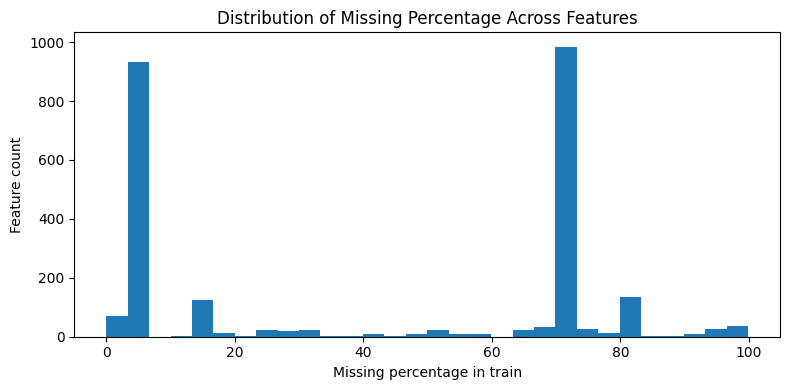

In [29]:
# Plot missing percentage distribution

plt.figure(figsize=(8, 4))
missingness_profile["missing_pct_train"].dropna().plot(kind="hist", bins=30)
plt.xlabel("Missing percentage in train")
plt.ylabel("Feature count")
plt.title("Distribution of Missing Percentage Across Features")
plt.tight_layout()
plt.savefig(missing_figure_dir / "missing_percentage_distribution.png", dpi=150)
plt.show()

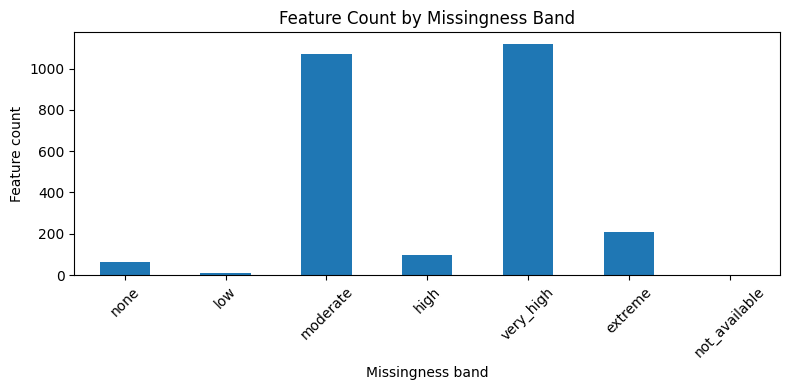

In [30]:
# Plot missingness band counts

plt.figure(figsize=(8, 4))
missingness_band_summary.plot(
    x="missingness_band_train",
    y="feature_count",
    kind="bar",
    legend=False,
    ax=plt.gca()
)
plt.xlabel("Missingness band")
plt.ylabel("Feature count")
plt.title("Feature Count by Missingness Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(missing_figure_dir / "missingness_band_count.png", dpi=150)
plt.show()

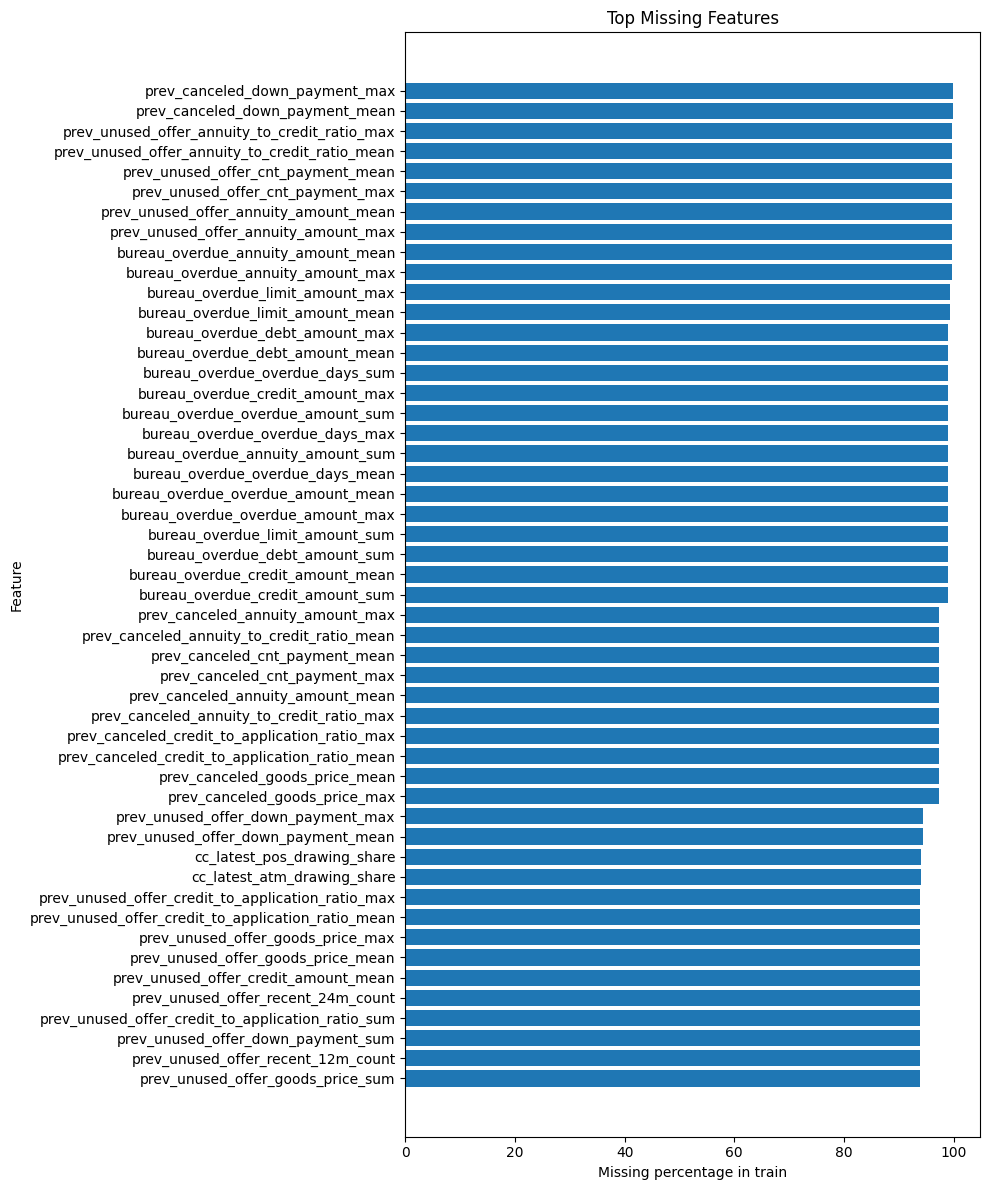

In [31]:
# Plot top missing features

top_missing_plot = top_missing_features.head(50).sort_values("missing_pct_train")

plt.figure(figsize=(10, 12))
plt.barh(top_missing_plot["feature"], top_missing_plot["missing_pct_train"])
plt.xlabel("Missing percentage in train")
plt.ylabel("Feature")
plt.title("Top Missing Features")
plt.tight_layout()
plt.savefig(missing_figure_dir / "top_missing_features.png", dpi=150)
plt.show()

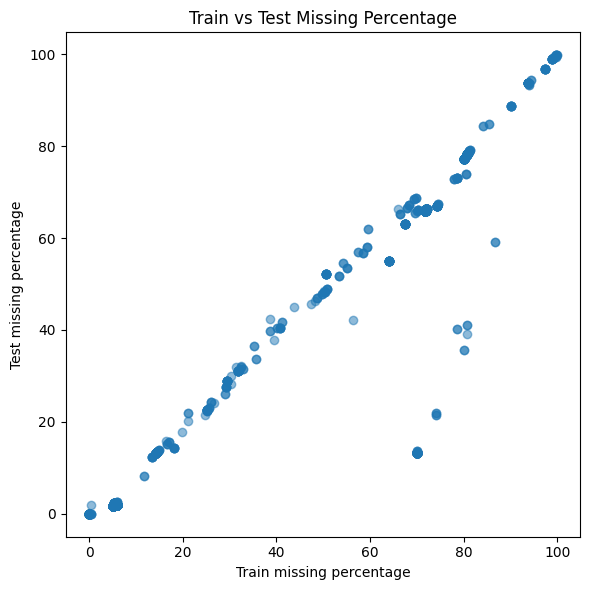

In [32]:
# Plot train-test missing percentage scatter

scatter_data = missingness_profile.dropna(
    subset=["missing_pct_train", "missing_pct_test"]
)

plt.figure(figsize=(6, 6))
plt.scatter(
    scatter_data["missing_pct_train"],
    scatter_data["missing_pct_test"],
    alpha=0.5
)
plt.xlabel("Train missing percentage")
plt.ylabel("Test missing percentage")
plt.title("Train vs Test Missing Percentage")
plt.tight_layout()
plt.savefig(missing_figure_dir / "train_test_missing_scatter.png", dpi=150)
plt.show()

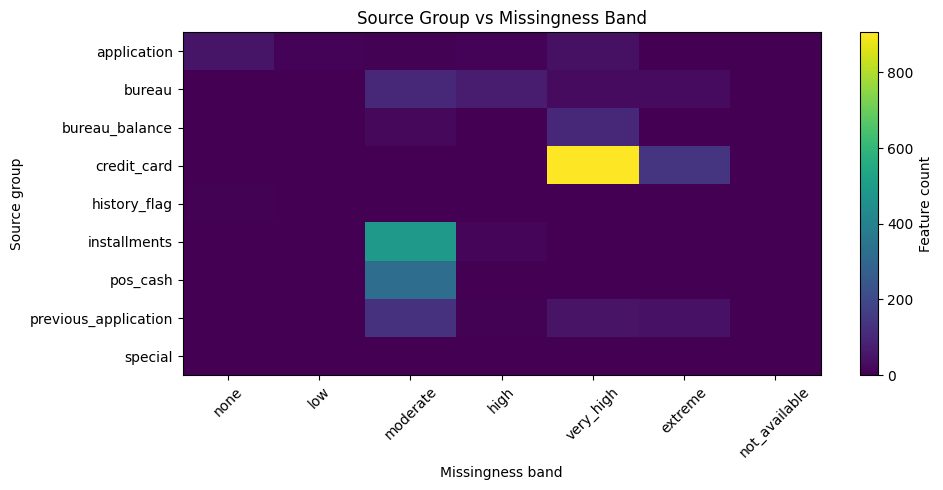

In [33]:
# Plot source group by missingness band heatmap

source_band_table = pd.crosstab(
    missingness_profile["source_group"],
    missingness_profile["missingness_band_train"]
)

source_band_table = source_band_table.reindex(columns=band_order, fill_value=0)

plt.figure(figsize=(10, 5))
plt.imshow(source_band_table.values, aspect="auto")
plt.xticks(range(len(source_band_table.columns)), source_band_table.columns, rotation=45)
plt.yticks(range(len(source_band_table.index)), source_band_table.index)
plt.xlabel("Missingness band")
plt.ylabel("Source group")
plt.title("Source Group vs Missingness Band")
plt.colorbar(label="Feature count")
plt.tight_layout()
plt.savefig(missing_figure_dir / "source_group_missingness_heatmap.png", dpi=150)
plt.show()

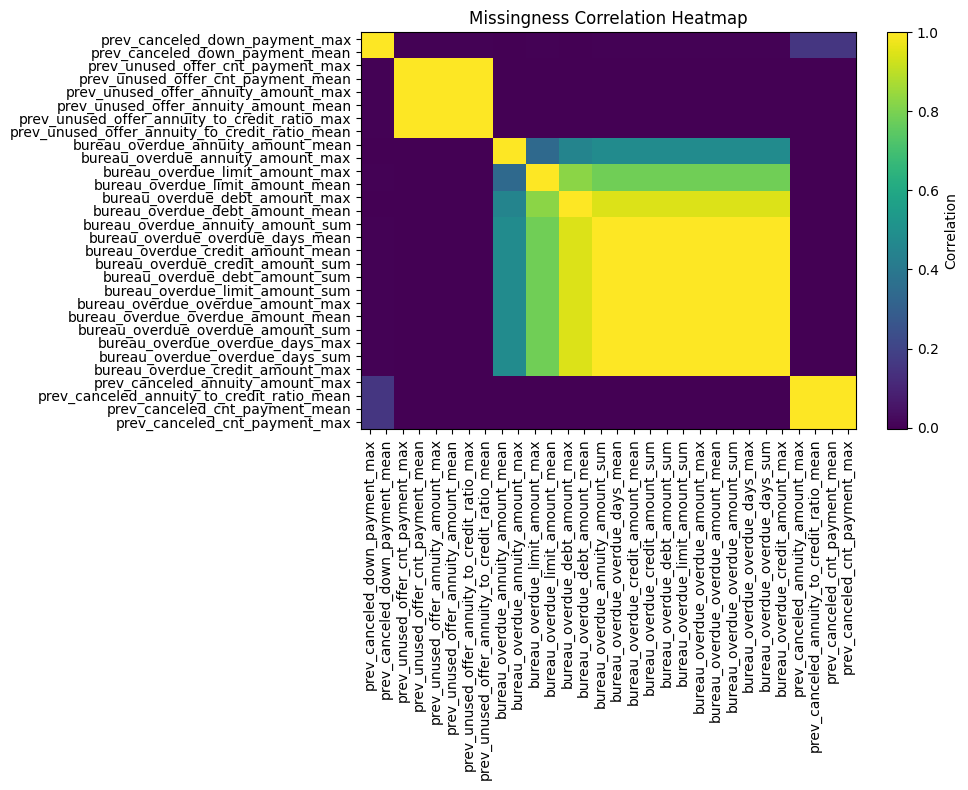

In [34]:
# Plot missingness correlation heatmap for selected features

top_corr_heatmap_features = corr_features[:30]

if len(top_corr_heatmap_features) >= 2:
    corr_heatmap = train_df[top_corr_heatmap_features].isna().astype("int8").corr()
    
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_heatmap.values, aspect="auto")
    plt.xticks(range(len(corr_heatmap.columns)), corr_heatmap.columns, rotation=90)
    plt.yticks(range(len(corr_heatmap.index)), corr_heatmap.index)
    plt.title("Missingness Correlation Heatmap")
    plt.colorbar(label="Correlation")
    plt.tight_layout()
    plt.savefig(missing_figure_dir / "missingness_correlation_heatmap.png", dpi=150)
    plt.show()

In [35]:
# Save missingness reports

missingness_profile_path = missing_report_dir / "missingness_profile.csv"
missingness_summary_path = missing_report_dir / "missingness_summary_report.csv"

missingness_profile.to_csv(missingness_profile_path, index=False)

summary_tables = {
    "missingness_band_summary": missingness_band_summary,
    "source_group_missing_summary": source_group_missing_summary,
    "top_missing_features": top_missing_features,
    "top_missing_gap_features": top_missing_gap_features,
    "missing_corr_pairs": missing_corr_pairs
}

with open(missingness_summary_path, "w", encoding="utf-8") as file:
    for table_name, table in summary_tables.items():
        file.write(table_name + "\n")
        table.to_csv(file, index=False)
        file.write("\n\n")

pd.DataFrame({
    "report": [
        "missingness_profile",
        "missingness_summary_report",
        "missingness_figures"
    ],
    "path": [
        str(missingness_profile_path),
        str(missingness_summary_path),
        str(missing_figure_dir)
    ]
})

,report,path
0,missingness_profile,reports\missingness\missingness_profile.csv
1,missingness_summary_report,reports\missingness\missingness_summary_report...
2,missingness_figures,reports\missingness\figures


### 2.3 Manual Summary Insight

The missingness report shows that missing values are a major structure of this dataset, not just a small data-quality issue.

Most features fall into the `moderate` and `very_high` missingness bands. Missingness is highly source-dependent, especially in the credit-card, bureau-balance, previous-application, and bureau feature groups.

The train-test missingness scatter shows that the overall missingness pattern is mostly aligned between train and test. However, some feature blocks, especially bureau-balance features, show large train-test missingness gaps and should be reviewed later before final modeling.

The source-group heatmap suggests that missingness is concentrated by data source. This is important because missing values in historical feature blocks may mean that the applicant has no prior record in that source table, not necessarily that the data is wrong.

The missingness correlation heatmap also shows block-level missingness. Some groups of features are missing together, especially bureau-overdue and previous-application canceled or unused-offer features. This means later feature selection should check redundancy among features with similar missingness patterns.

At this stage, no model feature will be dropped only because it has high missingness.

The only safe automatic exclusions are non-feature columns such as ID, target, and accidental index artifacts.

Possible later preprocessing direction:

| Feature Situation | Possible Later Handling |
|---|---|
| No missing values | No imputation needed |
| Low/moderate missing numeric features | Median imputation |
| High-missing application property features | Median imputation + missing indicator |
| Missing external score features | Median imputation + missing indicator |
| Historical count/sum features missing because of no history | Possible 0 fill + source/history flag |
| High-missing ratio/amount history features | Review meaning before choosing median or 0 |
| Categorical features with missing values | Treat missing as a separate category |
| Binary/status features with missing values | Treat missing as unknown or add missing indicator |

Final note: missingness will be carried forward as evidence. Final imputation, feature dropping, and missing-indicator decisions will be made later after checking feature meaning, target relationship, redundancy, and model validation.